## DeepMLP Architecture and Empirical Analysis of Gradient Dynamics on Fashion-MNIST

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

# Device configuration (MPS for Mac, CUDA for Nvidia, CPU fallback)
device = torch.device("mps" if torch.backends.mps.is_available() 
                      else "cuda" if torch.cuda.is_available() 
                      else "cpu")
print(f"Using device: {device}")

Using device: mps


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Loading FashionMNIST
full_train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 80/20 Validation Split
num_train = len(full_train_dataset)
indices = list(range(num_train))
split = int(np.floor(0.2 * num_train))

train_idx, val_idx = indices[split:], indices[:split]
train_loader = DataLoader(full_train_dataset, batch_size=64, sampler=torch.utils.data.SubsetRandomSampler(train_idx))
val_loader = DataLoader(full_train_dataset, batch_size=64, sampler=torch.utils.data.SubsetRandomSampler(val_idx))
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [15]:
class DeepMLP(nn.Module):
    def __init__(self, activation_layer):
        super(DeepMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            activation_layer,
            nn.Linear(512, 256),
            activation_layer,
            nn.Linear(256, 128),
            activation_layer,
            nn.Linear(128, 64),
            activation_layer,
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.layers(x)

In [16]:
def check_gradient_norm(activation_type, activation_fn):
    model = DeepMLP(activation_fn).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Get a single batch
    images, labels = next(iter(train_loader))
    images, labels = images.to(device), labels.to(device)
    
    # Forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)
    
    # Backward pass
    model.zero_grad()
    loss.backward()
    
    # Access the first layer's gradient norm
    first_layer_grad = model.layers[1].weight.grad.norm().item()
    print(f"Activation: {activation_type} | Input Layer Gradient Norm: {first_layer_grad:.6f}")
    return first_layer_grad

# Running the experiment
sig_grad = check_gradient_norm("Sigmoid", nn.Sigmoid())
relu_grad = check_gradient_norm("ReLU", nn.ReLU())

Activation: Sigmoid | Input Layer Gradient Norm: 0.001684
Activation: ReLU | Input Layer Gradient Norm: 0.124745


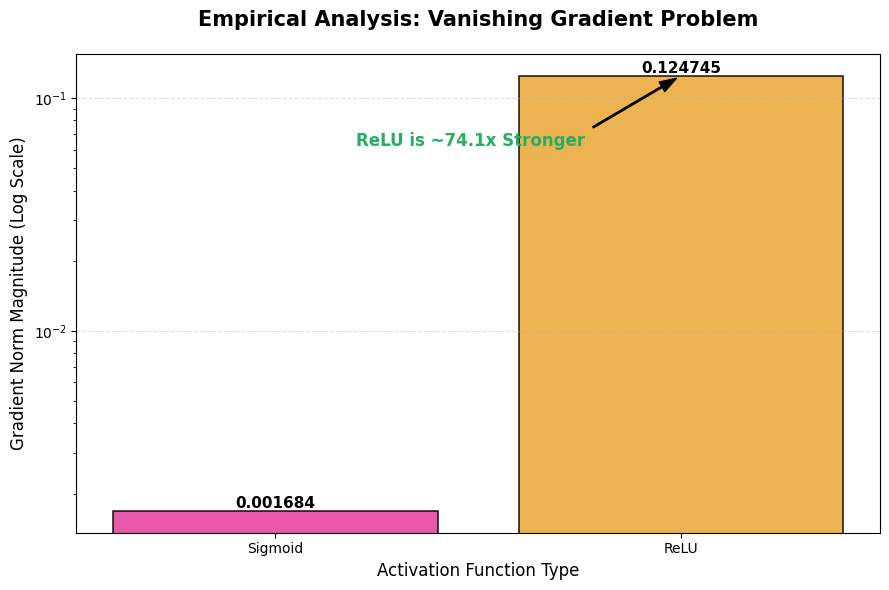

In [17]:
import matplotlib.pyplot as plt

activations = ['Sigmoid', 'ReLU']
gradients = [sig_grad, relu_grad] 

plt.figure(figsize=(9, 6))


colors = ["#e73c9a", "#eaa632"]
bars = plt.bar(activations, gradients, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)

plt.yscale('log')

plt.title('Empirical Analysis: Vanishing Gradient Problem', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Gradient Norm Magnitude (Log Scale)', fontsize=12)
plt.xlabel('Activation Function Type', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.6f}', 
             va='bottom', ha='center', fontsize=11, fontweight='bold', color='black')

diff_factor = relu_grad / sig_grad
plt.annotate(f'ReLU is ~{diff_factor:.1f}x Stronger', 
             xy=(1, relu_grad), xytext=(0.2, relu_grad/2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=12, fontweight='bold', color='#27ae60')

plt.tight_layout()
plt.show()